# Pipelines

A `Pipeline` wires functions and stream operators into a reusable computation you
define once and run either on stored arrays or live, event by event. Run it over
whole arrays in one pass, or feed it events one at a time as they arrive; both
paths give identical results.

The example is a smoothed spread over two price feeds. The concepts behind the
pipeline are in [Pipelines](../pipelines.md).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from screamer import Input, Pipeline, RollingMean, Sub
from screamer import CombineLatest

## Building the pipeline

`Input(name)` creates a named source. Applying stream operators and functions to
those nodes builds more nodes: `CombineLatest` aligns the two feeds into one
two-column stream, `Sub()` takes their difference, and `RollingMean(20)` smooths
it. Building the pipeline only records structure; nothing runs until you call it. Compiling it
into a `Pipeline` names which nodes are inputs and which are outputs.

In [2]:
a, b = Input("a"), Input("b")

aligned = CombineLatest()(a, b)    # align the two feeds -> a node
spread  = Sub()(aligned)           # difference          -> a node
signal  = RollingMean(20)(spread)  # smooth              -> a node

pipe = Pipeline(inputs=[a, b], outputs=[signal])

## Inspecting the pipeline

`print(pipe)` shows the pipeline as an indented tree, rooted at each output and descending to the inputs, with each node's parameters in its label. This requires no optional dependencies, so it works in any environment. Each node also carries an id (`#2`); a node shared by several consumers is printed once and then referenced by that id.

In [3]:
print(pipe)

Pipeline(2 input(s), 1 output(s), align_outputs=True)
out[0] = RollingMean(window_size=20)  #4
   └─ Sub()  #3
      └─ CombineLatest(emit='when_all')  #2
         ├─ a  #0 (input)
         └─ b  #1 (input)


The same graph is available as a Graphviz DOT string via `pipe.to_dot()`, which you
can feed to any DOT renderer.

In [4]:
print(pipe.to_dot())

digraph screamer_dag {
  rankdir=LR;
  node [fontname="monospace"];
  n0 [label="a", shape=ellipse, style=filled, fillcolor="#e8f0fe"];
  n1 [label="b", shape=ellipse, style=filled, fillcolor="#e8f0fe"];
  n2 [label="CombineLatest(emit='when_all')", shape=box, style="rounded,filled", fillcolor="#fff3e0"];
  n3 [label="Sub()", shape=box, style=filled, fillcolor="#f5f5f5"];
  n4 [label="RollingMean(window_size=20)", shape=box, style=filled, fillcolor="#f5f5f5", penwidth=2, color="#1a73e8"];
  n0 -> n2;
  n1 -> n2;
  n2 -> n3;
  n3 -> n4;
}


In a notebook, displaying the `pipe` object directly renders that diagram inline.

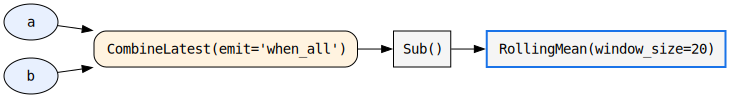

In [5]:
pipe.to_graphviz()

## Running it: batch and live

`pipe(*feeds)` runs the whole pipeline over stored arrays in one pass. Pass
generators of `(value, index)` pairs instead of arrays to run event by event:
`pipe(gen_a, gen_b)` returns an iterator of `(value, index)` events. Each feed is
a `(values, index)` pair.

In [6]:
rng = np.random.default_rng(0)
n = 200
index = np.arange(1, n + 1, dtype=np.int64)
fa = (100 + np.cumsum(rng.standard_normal(n)), index)   # two feeds on the
fb = (100 + np.cumsum(rng.standard_normal(n)), index)   # same timeline

batch_v, batch_idx = pipe(fa, fb)          # whole arrays in

# Event by event via generators
gen_a = ((v, k) for v, k in zip(fa[0], fa[1]))
gen_b = ((v, k) for v, k in zip(fb[0], fb[1]))
events = list(pipe(gen_a, gen_b))
live_v   = np.array([e[0] for e in events])
live_idx = np.array([e[1] for e in events])

import pandas as pd
m = ~np.isnan(batch_v)
pd.DataFrame({"batch": batch_v[m][:5], "live": live_v[m][:5]},
             index=batch_idx[m][:5]).rename_axis("index")

,batch,live
index,,
20,-0.025896,-0.025896
21,-0.360765,-0.360765
22,-0.550543,-0.550543
23,-0.853429,-0.853429
24,-1.141419,-1.141419


## Multiple outputs

A pipeline can expose more than one output. Adding `spread` alongside `signal` gives
back the raw difference and its smoothed version together, each as its own
`(values, index)` pair. With `align_outputs=True` (the default), all outputs are
co-indexed onto a shared sorted axis, so every pair has the same length and
outputs can be compared sample for sample. Set `align_outputs=False` to get
independent per-output streams whose lengths may differ.

In [7]:
dag2 = Pipeline(inputs=[a, b], outputs=[spread, signal])
(raw_v, raw_idx), (sig_v, sig_idx) = dag2(fa, fb)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(raw_idx, raw_v, lw=0.6, color="0.7", label="spread (raw)")
ax.plot(sig_idx, sig_v, lw=1.6, color="crimson", label="RollingMean(20)")
ax.axhline(0, color="k", lw=0.4)
ax.set_xlabel("index")
ax.set_ylabel("a - b")
ax.legend(loc="upper left")
plt.tight_layout()

## Saving and reloading as JSON

`pipe.to_json()` serializes the whole pipeline, input names, every node with its
parameters, the outputs, and `align_outputs`, into readable JSON you can write to
a config file. `Pipeline.from_json(text)` rebuilds a runnable pipeline.
(`to_dict` / `from_dict` do the same with a plain dict.)

In [8]:
import json

config = pipe.to_json()
print(json.dumps(json.loads(config), indent=2))

restored = Pipeline.from_json(config)
restored_v, _ = restored(fa, fb)

{
  "screamer_dag": 1,
  "inputs": [
    "a",
    "b"
  ],
  "align_outputs": true,
  "nodes": [
    {
      "id": 0,
      "kind": "input",
      "name": "a"
    },
    {
      "id": 1,
      "kind": "input",
      "name": "b"
    },
    {
      "id": 2,
      "kind": "operator",
      "op": "CombineLatest",
      "params": {
        "emit": "when_all"
      },
      "in": [
        0,
        1
      ]
    },
    {
      "id": 3,
      "kind": "functor",
      "cls": "Sub",
      "params": {},
      "in": [
        2
      ]
    },
    {
      "id": 4,
      "kind": "functor",
      "cls": "RollingMean",
      "params": {
        "window_size": 20
      },
      "in": [
        3
      ]
    }
  ],
  "outputs": [
    4
  ]
}
